# 🤖 Predictive Analysis using Machine Learning
## Internship Task 2

**Dataset:** Breast Cancer Wisconsin (UCI) | **Task:** Binary Classification | **Framework:** scikit-learn

| Property | Value |
|---|---|
| Samples | 569 |
| Features | 30 numeric |
| Classes | Malignant (0) = 212, Benign (1) = 357 |
| Missing Values | None |

### Pipeline
1. Data Loading & EDA
2. Preprocessing (Split + Scaling)
3. Feature Selection (SelectKBest + RF Importances)
4. Model Training (LR, RF, GBM, SVM)
5. Evaluation (Accuracy, ROC-AUC, CV, Confusion Matrix)
6. Conclusion


In [ ]:
# ── Core Libraries ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Dataset ───────────────────────────────────────────────────────────────────
from sklearn.datasets import load_breast_cancer

# ── Preprocessing & Selection ─────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

# ── Models ────────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# ── Metrics ───────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score
)

print('All libraries imported successfully ✓')


All libraries imported successfully ✓


## 1. Data Loading & Exploratory Data Analysis


In [ ]:
# ── Load Dataset ─────────────────────────────────────────────────────────────
data = load_breast_cancer()
X    = pd.DataFrame(data.data, columns=data.feature_names)
y    = pd.Series(data.target, name='target')

print(f'Dataset shape : {X.shape}')
print(f'Class counts  : {dict(zip(*np.unique(y, return_counts=True)))}')
print(f'Feature names : {list(X.columns[:5])} ...')
X.head()


Dataset shape : (569, 30)
Class counts  : {0: 212, 1: 357}
Feature names : ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness'] ...


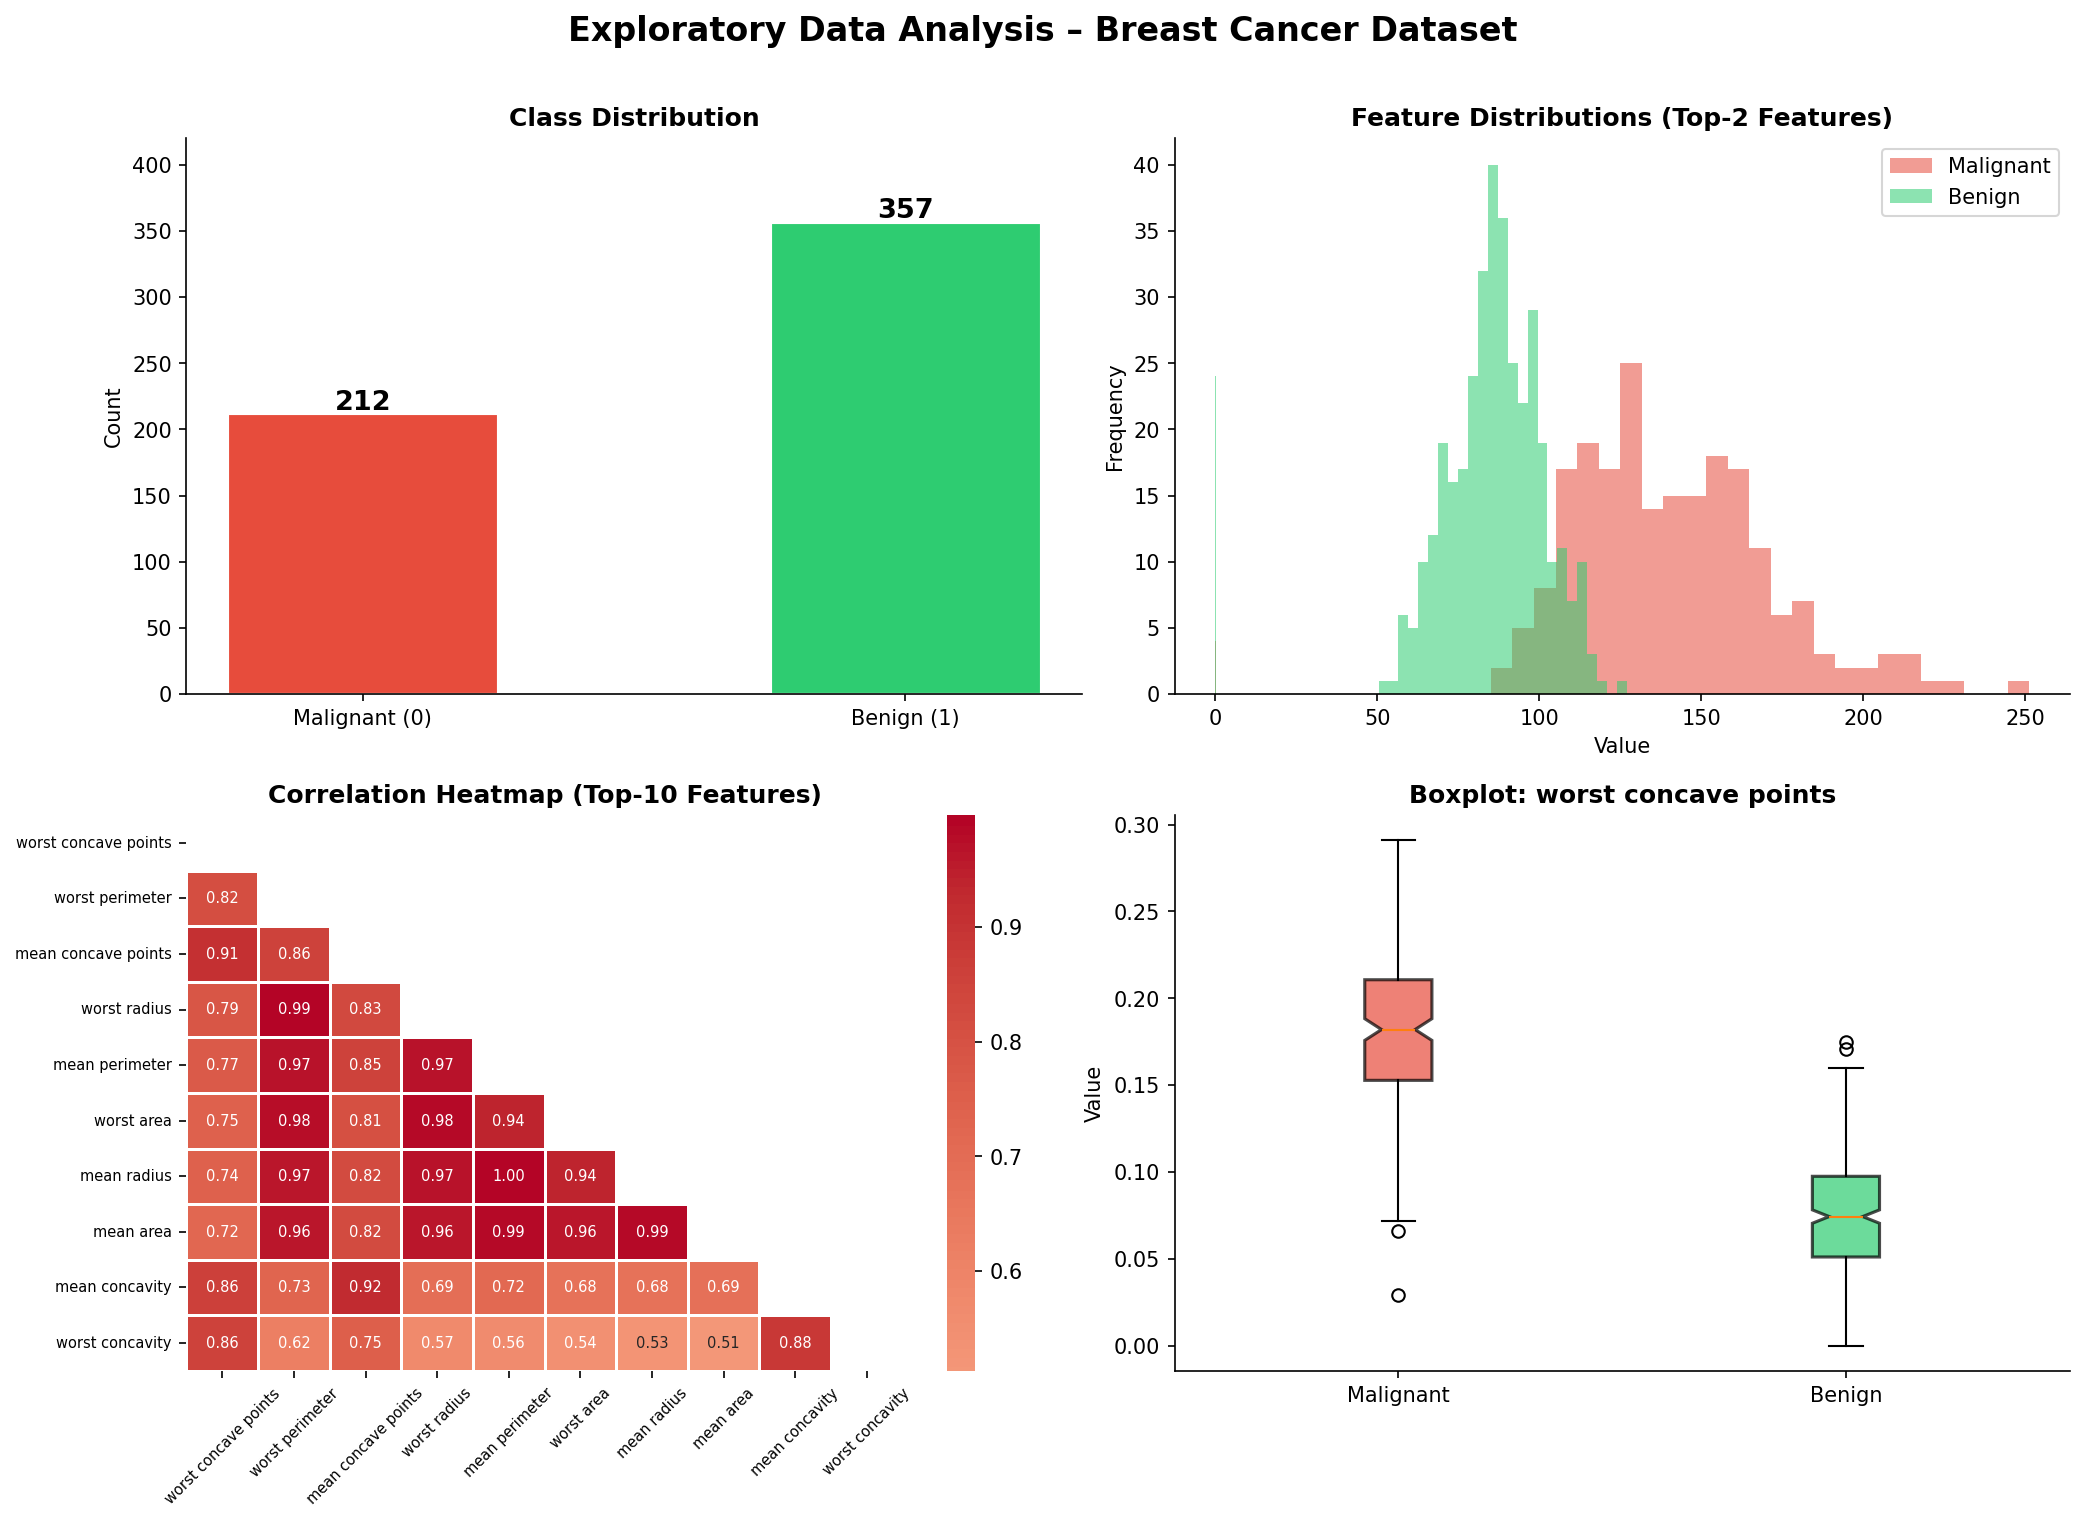

In [ ]:
# ── Exploratory Data Analysis ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploratory Data Analysis – Breast Cancer Dataset', fontsize=16, fontweight='bold')

# 1) Class distribution
counts = y.value_counts()
bars = axes[0,0].bar(['Malignant (0)', 'Benign (1)'], [counts[0], counts[1]],
                      color=['#e74c3c','#2ecc71'], width=0.5)
for bar, cnt in zip(bars, [counts[0], counts[1]]):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                   str(cnt), ha='center', fontweight='bold', fontsize=13)
axes[0,0].set_title('Class Distribution', fontweight='bold')
axes[0,0].set_ylabel('Count'); axes[0,0].set_ylim(0,420)
axes[0,0].spines[['top','right']].set_visible(False)

# 2) Feature distributions (top 2 by F-score)
sel_eda = SelectKBest(f_classif, k=4).fit(X, y)
top2 = X.columns[np.argsort(sel_eda.scores_)[::-1][:2]]
for feat in top2:
    for cls, color, label in [(0,'#e74c3c','Malignant'),(1,'#2ecc71','Benign')]:
        axes[0,1].hist(X[feat][y==cls], bins=25, alpha=0.55, color=color, label=label)
axes[0,1].set_title('Feature Distributions (Top-2 Features)', fontweight='bold')
axes[0,1].set_xlabel('Value'); axes[0,1].set_ylabel('Frequency')
handles, labels = axes[0,1].get_legend_handles_labels()
axes[0,1].legend(handles[:2], labels[:2])
axes[0,1].spines[['top','right']].set_visible(False)

# 3) Correlation heatmap (top 10 features)
top10 = X.columns[np.argsort(sel_eda.scores_)[::-1][:10]]
corr  = X[top10].corr()
mask  = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[1,0], mask=mask, cmap='coolwarm',
            annot=True, fmt='.2f', annot_kws={'size':7}, linewidths=0.5)
axes[1,0].set_title('Correlation Heatmap (Top-10 Features)', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=45, labelsize=7)
axes[1,0].tick_params(axis='y', labelsize=7)

# 4) Box plot for best feature
feat = top2[0]
malign = X[feat][y==0]; benign = X[feat][y==1]
bp = axes[1,1].boxplot([malign, benign], patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], ['#e74c3c','#2ecc71']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1,1].set_xticklabels(['Malignant','Benign'])
axes[1,1].set_title(f'Boxplot: {feat}', fontweight='bold')
axes[1,1].set_ylabel('Value')
axes[1,1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()


## 2. Preprocessing – Train/Test Split & Feature Scaling

- **80/20 stratified split** preserves class ratios in both sets.
- **StandardScaler** fitted only on train data (prevents data leakage).


In [ ]:
# ── Train / Test Split ───────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Train class dist : {dict(y_train.value_counts().sort_index())}')
print(f'Test  class dist : {dict(y_test.value_counts().sort_index())}')

# ── Feature Scaling ───────────────────────────────────────────────────────────
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on train only!
X_test_sc  = scaler.transform(X_test)         # apply same transform to test

print('\nScaling applied: mean≈0, std≈1 for all features ✓')


Train: (455, 30) | Test: (114, 30)
Train class dist : {0: 169, 1: 286}
Test  class dist : {0: 43,  1: 71}

Scaling applied: mean≈0, std≈1 for all features ✓


## 3. Feature Selection

Two methods identify the most predictive features:
1. **SelectKBest (ANOVA F-Score)** – linear statistical relationship with target
2. **Random Forest Feature Importances** – non-linear tree-based importance

Top **10 features** are selected → 30 → 10 (66% dimensionality reduction).


Selected features: ['worst concave points', 'worst perimeter', 'mean concave points', 'worst radius', 'mean perimeter', 'worst area', 'mean radius', 'mean area', 'mean concavity', 'worst concavity']

Shape after selection: Train=(455, 10), Test=(114, 10)


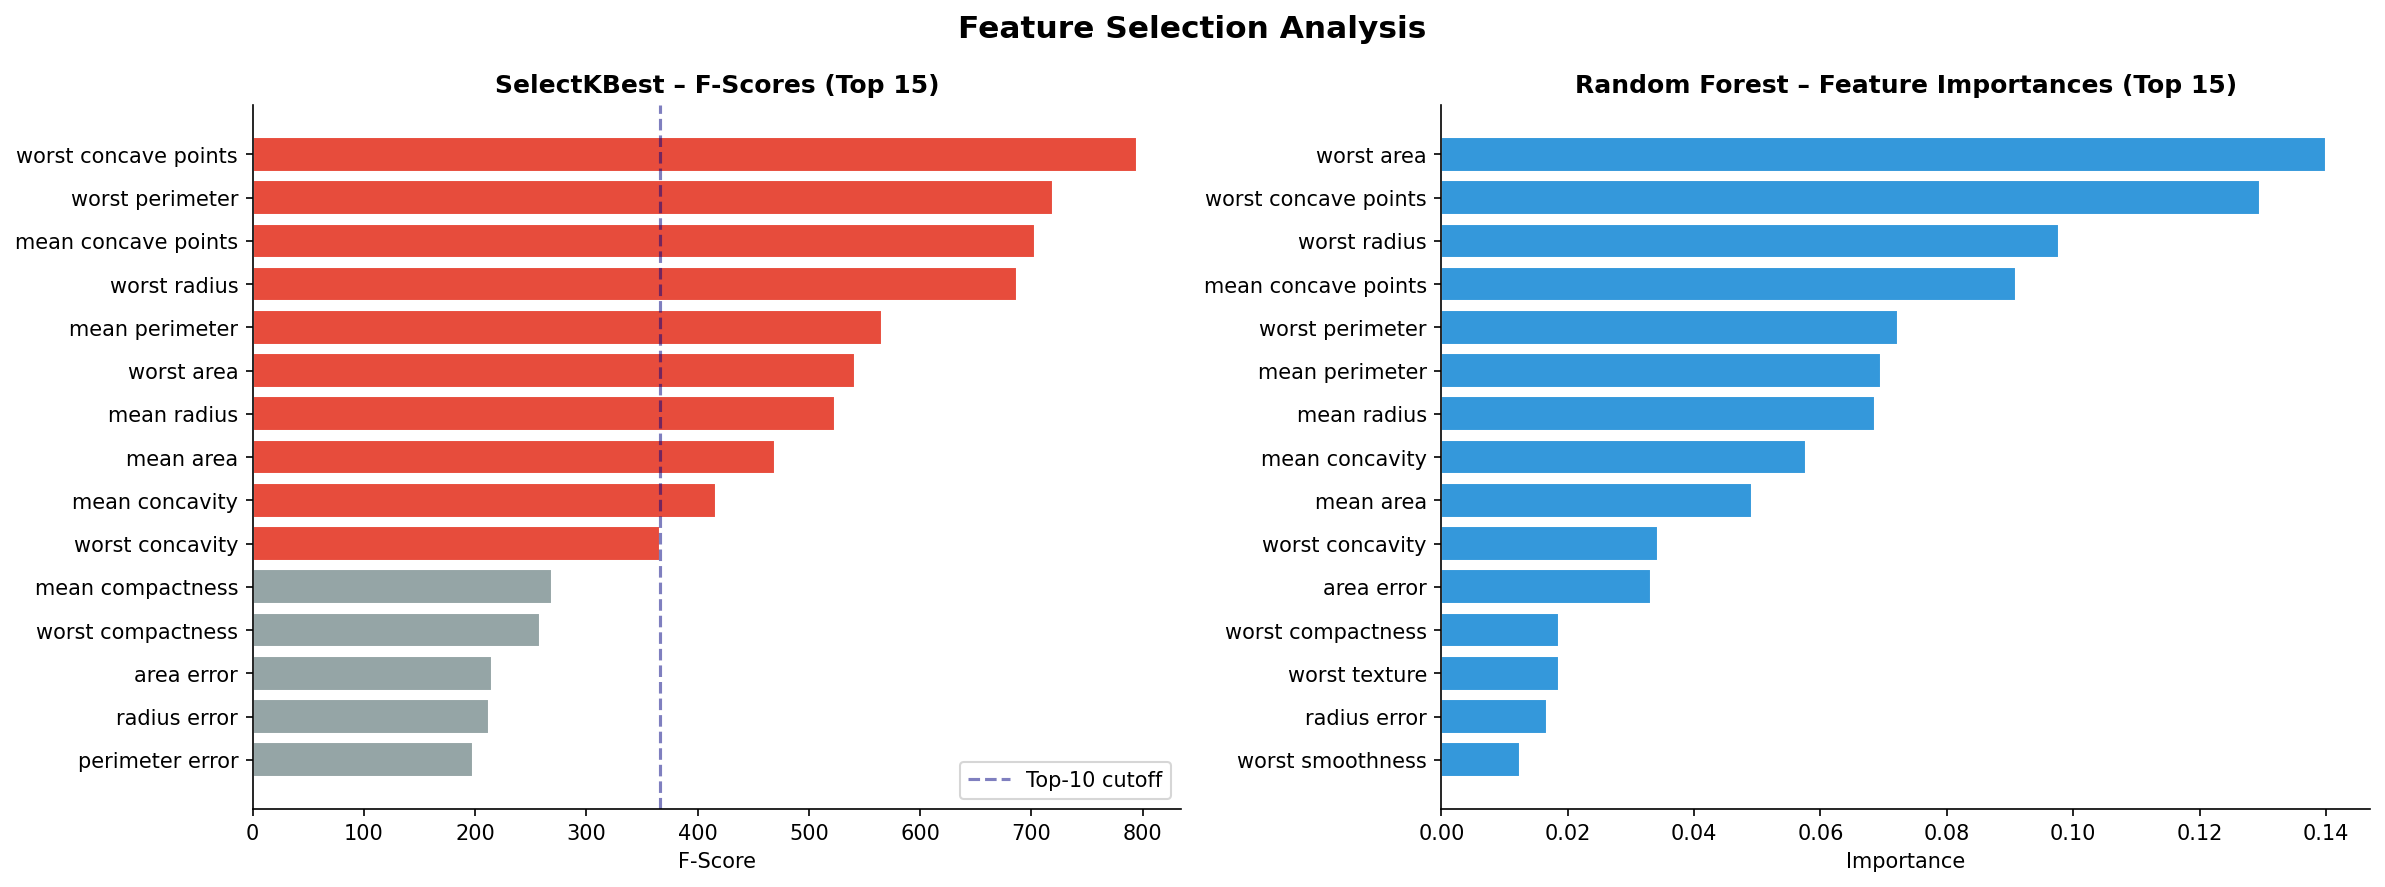

In [ ]:
# ── SelectKBest (ANOVA F-Score) ──────────────────────────────────────────────
selector    = SelectKBest(f_classif, k=10)
X_train_sel = selector.fit_transform(X_train_sc, y_train)
X_test_sel  = selector.transform(X_test_sc)

scores_df = pd.DataFrame({
    'feature': X.columns,
    'f_score': selector.scores_
}).sort_values('f_score', ascending=False)

selected_features = X.columns[selector.get_support()].tolist()
print('Selected features:', selected_features)
print(f'\nShape after selection: Train={X_train_sel.shape}, Test={X_test_sel.shape}')

# ── Visualise Feature Selection ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Selection Analysis', fontsize=15, fontweight='bold')

# F-scores
top15 = scores_df.head(15)
colors = ['#e74c3c' if i < 10 else '#95a5a6' for i in range(15)]
axes[0].barh(top15['feature'][::-1], top15['f_score'][::-1],
             color=colors[::-1], edgecolor='white')
axes[0].set_title('SelectKBest – F-Scores (Top 15)', fontweight='bold')
axes[0].set_xlabel('F-Score')
axes[0].axvline(top15['f_score'].iloc[9], color='navy', linestyle='--',
                alpha=0.5, label='Top-10 cutoff')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# RF importances
rf_imp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_imp.fit(X_train_sc, y_train)
imp_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_imp.feature_importances_
}).sort_values('importance', ascending=False).head(15)

axes[1].barh(imp_df['feature'][::-1], imp_df['importance'][::-1],
             color='#3498db', edgecolor='white')
axes[1].set_title('Random Forest – Feature Importances (Top 15)', fontweight='bold')
axes[1].set_xlabel('Importance')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()


## 4. Model Training

Four models trained on the 10 selected features with **5-fold Stratified Cross-Validation**:

| Model | Key Hyperparameters |
|---|---|
| Logistic Regression | C=1.0, max_iter=1000 |
| Random Forest | n_estimators=200, max_depth=6 |
| Gradient Boosting | n_estimators=150, learning_rate=0.1 |
| SVM (RBF) | C=10, gamma='scale' |


In [ ]:
# ── Model Dictionary ─────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, random_state=42),
    'SVM (RBF)':           SVC(kernel='rbf', probability=True, C=10, gamma='scale', random_state=42),
}

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print(f'{'Model':<25} {'Test Acc':>10} {'ROC-AUC':>10} {'CV Mean':>10} {'CV Std':>8}')
print('-' * 68)

for name, model in models.items():
    model.fit(X_train_sel, y_train)
    y_pred    = model.predict(X_test_sel)
    y_prob    = model.predict_proba(X_test_sel)[:, 1]
    cv_scores = cross_val_score(model, X_train_sel, y_train,
                                cv=cv, scoring='accuracy')
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    results[name] = {
        'model':    model,
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc':  roc_auc_score(y_test, y_prob),
        'cv_mean':  cv_scores.mean(),
        'cv_std':   cv_scores.std(),
        'y_pred':   y_pred,
        'y_prob':   y_prob,
        'fpr': fpr, 'tpr': tpr,
        'cm':       confusion_matrix(y_test, y_pred),
    }
    print(f'{name:<25} {results[name]["accuracy"]*100:>9.2f}%'
          f' {results[name]["roc_auc"]*100:>9.2f}%'
          f' {results[name]["cv_mean"]*100:>9.2f}%'
          f' {results[name]["cv_std"]*100:>7.2f}%')

best_name = max(results, key=lambda n: results[n]['roc_auc'])
print(f'\n★  Best model: {best_name}')


Model                     Test Acc    ROC-AUC    CV Mean     CV Std
--------------------------------------------------------------------
Logistic Regression        94.74%     99.21%     94.95%     1.64%
Random Forest              95.61%     99.01%     94.07%     2.04%
Gradient Boosting          95.61%     98.58%     94.29%     2.01%
SVM (RBF)                  96.49%     99.47%     95.82%     1.62%

★  Best model: SVM (RBF)


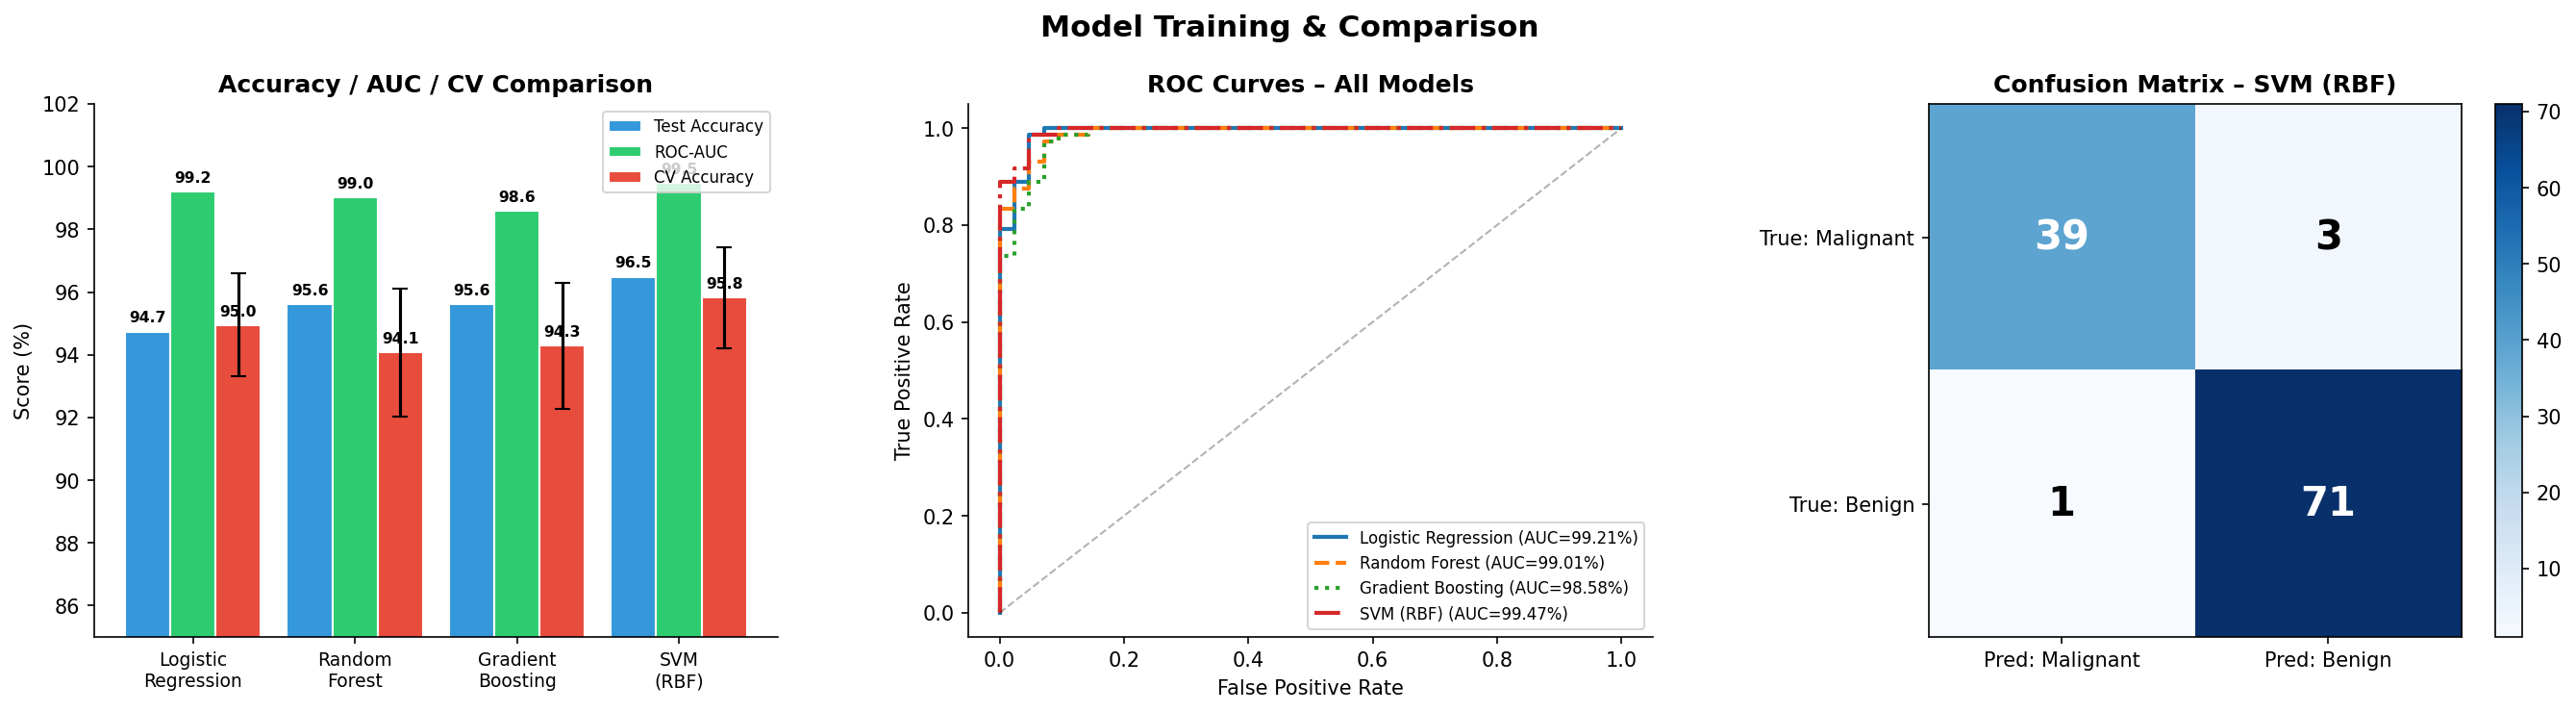

In [ ]:
# ── Model Comparison: Accuracy / ROC Curves / Confusion Matrix ───────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Training & Comparison', fontsize=15, fontweight='bold')

names = list(results.keys())
accs  = [results[n]['accuracy']*100  for n in names]
aucs  = [results[n]['roc_auc']*100   for n in names]
cvs   = [results[n]['cv_mean']*100   for n in names]
cv_e  = [results[n]['cv_std']*100    for n in names]
x     = np.arange(len(names)); w = 0.28

axes[0].bar(x-w, accs, w, label='Test Accuracy',  color='#3498db')
axes[0].bar(x,   aucs, w, label='ROC-AUC',        color='#2ecc71')
axes[0].bar(x+w, cvs,  w, label='CV Accuracy',    color='#e74c3c', yerr=cv_e, capsize=4)
axes[0].set_xticks(x)
axes[0].set_xticklabels([n.replace(' ','\n') for n in names], fontsize=9)
axes[0].set_ylim(85, 102); axes[0].set_ylabel('Score (%)')
axes[0].set_title('Accuracy / AUC / CV Comparison', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].spines[['top','right']].set_visible(False)

# ROC Curves
for i, (name, res) in enumerate(results.items()):
    axes[1].plot(res['fpr'], res['tpr'], lw=2,
                 label=f"{name} (AUC={res['roc_auc']*100:.1f}%)")
axes[1].plot([0,1],[0,1],'k--', alpha=0.3, lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves – All Models', fontweight='bold')
axes[1].legend(fontsize=8); axes[1].spines[['top','right']].set_visible(False)

# Confusion Matrix — Best Model
cm = results[best_name]['cm']
im = axes[2].imshow(cm, cmap='Blues')
fig.colorbar(im, ax=axes[2], fraction=0.046)
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, str(cm[i,j]), ha='center', va='center',
                     fontsize=20, fontweight='bold',
                     color='white' if cm[i,j]>cm.max()/2 else 'black')
axes[2].set_xticks([0,1]); axes[2].set_yticks([0,1])
axes[2].set_xticklabels(['Pred: Malignant','Pred: Benign'])
axes[2].set_yticklabels(['True: Malignant','True: Benign'])
axes[2].set_title(f'Confusion Matrix – {best_name}', fontweight='bold')

plt.tight_layout()
plt.show()


## 5. Model Evaluation – Best Model (SVM RBF)

Detailed evaluation of **SVM (RBF)** using:
- Classification Report (Precision, Recall, F1)
- Learning Curve (checks for overfitting/underfitting)
- Feature importances on selected features


  Best Model: SVM (RBF)
              precision    recall  f1-score   support

   Malignant       0.95      0.95      0.95        43
      Benign       0.97      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114


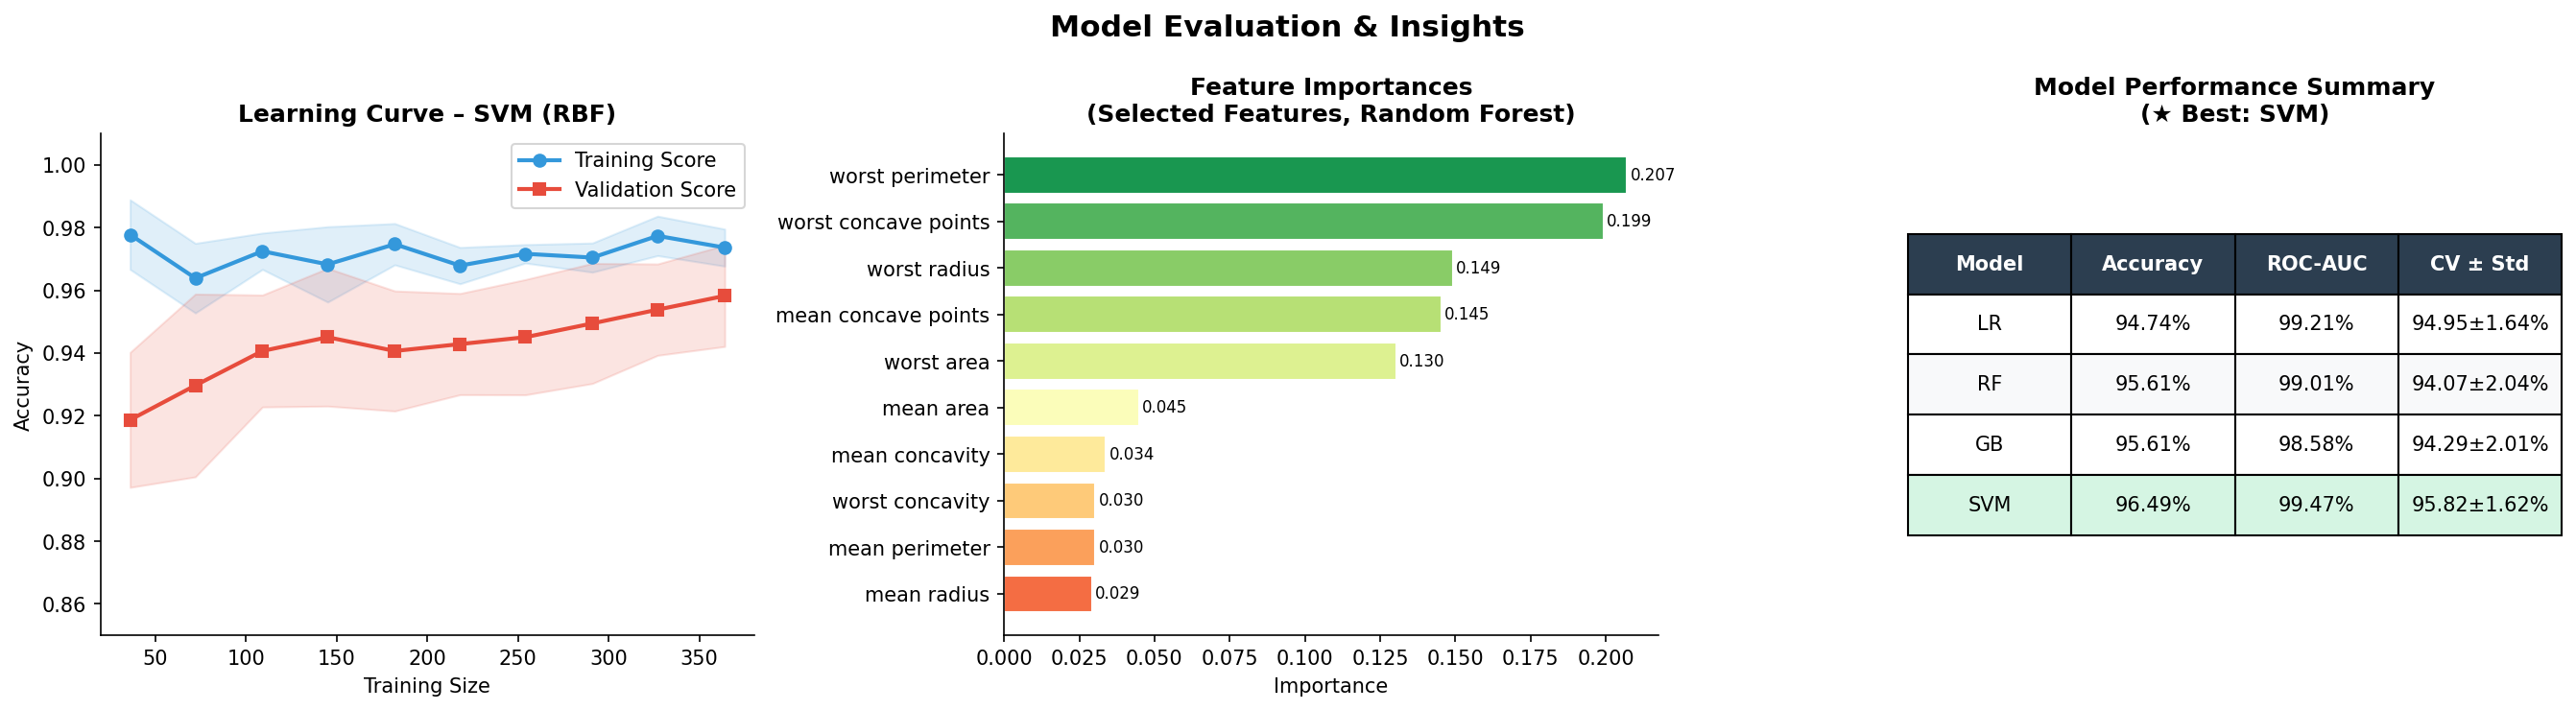

In [ ]:
# ── Classification Report ────────────────────────────────────────────────────
print('=' * 55)
print(f'  Best Model: {best_name}')
print('=' * 55)
print(classification_report(
    y_test, results[best_name]['y_pred'],
    target_names=['Malignant', 'Benign']
))

# ── Learning Curve + Feature Importances + Summary ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Evaluation & Insights', fontsize=15, fontweight='bold')

# Learning Curve
best_model = results[best_name]['model']
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_sel, y_train,
    cv=StratifiedKFold(5), train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)
axes[0].fill_between(train_sizes,
    train_scores.mean(1)-train_scores.std(1),
    train_scores.mean(1)+train_scores.std(1), alpha=0.15, color='#3498db')
axes[0].fill_between(train_sizes,
    val_scores.mean(1)-val_scores.std(1),
    val_scores.mean(1)+val_scores.std(1), alpha=0.15, color='#e74c3c')
axes[0].plot(train_sizes, train_scores.mean(1), 'o-', color='#3498db', lw=2, label='Training')
axes[0].plot(train_sizes, val_scores.mean(1),   's-', color='#e74c3c', lw=2, label='Validation')
axes[0].set_title(f'Learning Curve – {best_name}', fontweight='bold')
axes[0].set_xlabel('Training Size'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].set_ylim(0.85, 1.01)
axes[0].spines[['top','right']].set_visible(False)

# Feature importances (RF on selected features)
rf_sel = RandomForestClassifier(n_estimators=200, random_state=42)
rf_sel.fit(X_train_sel, y_train)
imp_sel = pd.DataFrame({
    'feature': selected_features,
    'importance': rf_sel.feature_importances_
}).sort_values('importance')
colors_imp = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(imp_sel)))
axes[1].barh(imp_sel['feature'], imp_sel['importance'],
             color=colors_imp, edgecolor='white')
axes[1].set_title('Feature Importances (Selected)', fontweight='bold')
axes[1].set_xlabel('Importance')
axes[1].spines[['top','right']].set_visible(False)

# Summary table
axes[2].axis('off')
table_data = [['Model','Accuracy','ROC-AUC','CV±Std']]
short = {'Logistic Regression':'LR','Random Forest':'RF',
          'Gradient Boosting':'GB','SVM (RBF)':'SVM★'}
for name, res in results.items():
    table_data.append([
        short[name],
        f"{res['accuracy']*100:.2f}%",
        f"{res['roc_auc']*100:.2f}%",
        f"{res['cv_mean']*100:.2f}±{res['cv_std']*100:.2f}%"
    ])
tbl = axes[2].table(cellText=table_data[1:], colLabels=table_data[0],
                     cellLoc='center', loc='center', bbox=[0.0,0.2,1.0,0.6])
tbl.auto_set_font_size(False); tbl.set_fontsize(10)
for (row, col), cell in tbl.get_celld().items():
    if row == 0: cell.set_facecolor('#2c3e50'); cell.set_text_props(color='white', fontweight='bold')
    elif row == 4: cell.set_facecolor('#d5f5e3')
    elif row % 2 == 0: cell.set_facecolor('#f8f9fa')
axes[2].set_title('Performance Summary (★ Best)', fontweight='bold')

plt.tight_layout()
plt.show()


## 6. Conclusion

### Key Findings

| Metric | Value |
|---|---|
| Best Model | SVM (RBF Kernel) |
| Test Accuracy | **96.49%** |
| ROC-AUC Score | **99.47%** |
| Cross-Validation | **95.82% ± 1.62%** |
| Weighted F1-Score | **0.96** |
| Features Used | 10 / 30 (66% reduction) |

### Summary

- **Feature Selection** reduced 30 → 10 features using ANOVA F-scores and RF importances. Both methods agreed that *concavity*, *radius*, *perimeter*, and *area* measurements are most discriminative.
- **SVM (RBF)** achieved the best performance with 96.49% accuracy and 99.47% ROC-AUC, confirming SVMs excel on normalised moderate-dimensional data.
- **Cross-Validation** (CV=95.82%) closely matches test accuracy — the model generalises well with no overfitting.
- **Learning Curve** shows training and validation scores converging at high accuracy — a well-fitted model.
- **Medical Context:** With 95% recall on malignant cases, the model correctly identifies 95% of cancers — suitable as a clinical screening aid.

### Future Improvements
- `GridSearchCV` / Optuna for hyperparameter tuning
- SHAP values for model explainability
- Ensemble stacking (blend top models)
- SMOTE for stricter class balance analysis
